# **Practice 06: Visualizing Relationships**

#### **Kelani Guyton**

---

**IMPORTANT**:
- Before starting the lab, save a copy to your google drive by navigating to `File > Save a copy in Drive` <br>

<br>


**Instructions**: Complete the lab below.

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed lab must be submitted to Canvas as a .ipynb file by the end of the lab session**
---

<br>

####<font color=red>Organized</font>

**Answers should be organized in the following format for organization and readability**


<font color=red>Example task 1</font>

In [ ]:
# 1.

# This will be the code block to answer the first part of a task

1. This will be the text answer/explanation (if prompted) for the first task

<font color=red>Example task 2</font>

In [ ]:
# 2.

# This will be the code block to answer the second part of a task

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

---

<br>

#### Packages

In [1]:
# install packages for today's lecture
install.packages("pheatmap")  # package for heatmap

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
# load the necessary packages
library(pheatmap)

<br>

<br>

<br>

---

####<font color=red>Task 1</font> - Loading and Preprocessing the Dataset



<font color=red>Task 1.1</font> Today, we'll be working with salary data available online. Run the following script to load the salary dataset for today's assignment.

```
data_url <- "https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/salary_data.csv"
salary   <- read.csv(data_url, header = TRUE)
```


In [3]:
data_url <- "https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/salary_data.csv"
salary   <- read.csv(data_url, header = TRUE)

<br>

<font color=red>Task 1.2</font> View the first few lines of the `salary` data frame using the `head()` function.

In [4]:
head(salary)

,Age,Gender,Education.Level,Job.Title,Years.of.Experience,Salary
,<int>,<chr>,<chr>,<chr>,<dbl>,<int>
1,32,Male,Bachelor's,Software Engineer,5,90000
2,28,Female,Master's,Data Analyst,3,65000
3,45,Male,PhD,Senior Manager,15,150000
4,36,Female,Bachelor's,Sales Associate,7,60000
5,52,Male,Master's,Director,20,200000
6,29,Male,Bachelor's,Marketing Analyst,2,55000


<br>

<font color=red>Task 1.3</font> Use the `str()` function to determine the number of rows and columns in the `salary` data frame. Write your observations in a text cell.

In [7]:
str(salary)

# dimensions
dim(salary)

'data.frame':	6704 obs. of  6 variables:
 $ Age                : int  32 28 45 36 52 29 42 31 26 38 ...
 $ Gender             : chr  "Male" "Female" "Male" "Female" ...
 $ Education.Level    : chr  "Bachelor's" "Master's" "PhD" "Bachelor's" ...
 $ Job.Title          : chr  "Software Engineer" "Data Analyst" "Senior Manager" "Sales Associate" ...
 $ Years.of.Experience: num  5 3 15 7 20 2 12 4 1 10 ...
 $ Salary             : int  90000 65000 150000 60000 200000 55000 120000 80000 45000 110000 ...


[1] 6704    6

There are 6704 observations (rows) and 6 variables (columns)

<br>

<font color=red>Task 1.4</font>

* Convert the `Gender` and `Education.Level` variables in factors and insert them in the data frame. You may overwrite the existing `Gender` and `Education.Level` variables
* Is the `Gender` variable a nominal or ordinal categorical variable?
* Is the `Education.Level` variable a nominal or ordinal categorical variable?

In [8]:
# convert to factor and over-write original
salary$Gender <- as.factor(salary$Gender)
salary$Education.Level <- as.factor(salary$Education.Level)

The `Gender` variable is a nominal categorical variable. The `Education.Level` is an ordinal categorical variable.

<font color=red>Task 1.5</font> Use the `levels()` function to view the unique categories of the `Education.Level` variable. What issues do you observe?

In [9]:
# check levels
levels(salary$Education.Level)

[1] ""                  "Bachelor's"        "Bachelor's Degree"
[4] "High School"       "Master's"          "Master's Degree"  
[7] "phD"               "PhD"

There are repeat categories. We can consolidate the repeat categories so they do not count as separate factor levels.

<font color=red>Task 1.6</font> Edit the levels of the `Education.Level` variable to the following:

* "missing"
* "BS"
* "HS"
* "MS"
* "PhD"

Hint: `levels(salary$Education.Level) <-  c(...)`

In [10]:
levels(salary$Education.Level) <- c("missing", "BS", "BS", "HS", "MS", "MS", "PhD", "PhD")

In [11]:
# check
levels(salary$Education.Level)

[1] "missing" "BS"      "HS"      "MS"      "PhD"

In [12]:
str(salary$Education.Level)
salary$Education.Level

 Factor w/ 5 levels "missing","BS",..: 2 4 5 2 4 2 4 2 2 5 ...


[1] BS      MS      PhD     BS      MS      BS      MS      BS      BS     
  [10] PhD     MS      BS      BS      MS      BS      BS      MS      PhD    
  [19] BS      BS      MS      MS      BS      BS      MS      BS      MS     
  [28] BS      PhD     MS      BS      BS      MS      BS      PhD     BS     
  [37] BS      MS      BS      BS      MS      MS      BS      BS      MS     
  [46] BS      BS      MS      PhD     BS      BS      MS      BS      MS     
  [55] BS      BS      MS      PhD     BS      MS      MS      BS      BS     
  [64] PhD     BS      MS      BS      BS      MS      MS      BS      BS     
  [73] PhD     BS      MS      BS      BS      MS      MS      BS      BS     
  [82] MS      BS      PhD     BS      MS      BS      BS      MS      BS     
  [91] PhD     BS      BS      MS      BS      BS      PhD     BS      MS     
 [100] BS      BS      MS      MS      BS      MS      PhD     BS      BS     
 [109] MS      BS      MS      BS      BS      MS      BS      MS      BS     
 [118] PhD     BS      MS      BS      MS      BS      BS      PhD     BS     
 [127] MS      BS      BS      MS      MS      BS      MS      PhD     BS     
 [136] BS      MS      BS      BS      MS      BS      MS      BS      BS     
 [145] MS      BS      PhD     BS      BS      MS      BS      MS      PhD    
 [154] BS      MS      BS      BS      MS      PhD     BS      BS      MS     
 [163] BS      BS      MS      BS      BS      PhD     BS      MS      MS     
 [172] BS      missing BS      MS      BS      PhD     BS      BS      MS     
 [181] BS      MS      PhD     BS      BS      BS      MS      BS      PhD    
 [190] BS      BS      MS      BS      BS      MS      BS      BS      PhD    
 [199] BS      MS      MS      BS      BS      MS      BS      PhD     BS     
 [208] BS      MS      BS      MS      PhD     BS      BS      BS      MS     
 [217] BS      PhD     BS      BS      MS      BS      BS      MS      BS     
 [226] BS      PhD     BS      MS      MS      BS      BS      MS      BS     
 [235] PhD     BS      BS      MS      BS      BS      PhD     BS      BS     
 [244] PhD     BS      BS      MS      BS      BS      MS      BS      MS     
 [253] PhD     BS      BS      BS      MS      BS      PhD     BS      missing
 [262] BS      PhD     BS      BS      BS      BS      MS      BS      BS     
 [271] PhD     BS      BS      MS      BS      BS      PhD     BS      BS     
 [280] MS      BS      BS      MS      BS      BS      PhD     BS      BS     
 [289] BS      BS      BS      PhD     BS      BS      MS      BS      BS     
 [298] PhD     BS      BS      MS      BS      BS      PhD     BS      BS     
 [307] MS      BS      BS      MS      BS      BS      PhD     BS      BS     
 [316] BS      MS      BS      BS      BS      MS      BS      BS      PhD    
 [325] BS      BS      PhD     BS      BS      MS      BS      BS      PhD    
 [334] BS      BS      MS      BS      BS      PhD     BS      BS      MS     
 [343] BS      BS      PhD     BS      BS      MS      BS      BS      PhD    
 [352] BS      BS      MS      BS      BS      PhD     BS      BS      MS     
 [361] BS      BS      PhD     BS      BS      MS      BS      BS      PhD    
 [370] BS      BS      MS      BS      BS      PhD     MS      BS      MS     
 [379] BS      PhD     BS      BS      MS      PhD     BS      MS      BS     
 [388] PhD     BS      BS      MS      PhD     BS      MS      BS      BS     
 [397] MS      BS      PhD     BS      BS      MS      PhD     BS      MS     
 [406] BS      PhD     BS      BS      MS      PhD     BS      MS      BS     
 [415] BS      MS      BS      PhD     BS      BS      MS      PhD     BS     
 [424] MS      BS      PhD     BS      BS      MS      PhD     BS      MS     
 [433] BS      BS      MS      BS      PhD     BS      BS      MS      PhD    
 [442] BS      MS      BS      PhD     BS      BS      MS      PhD     BS     
 [451] MS      BS      PhD     BS      BS      MS    

<br>

<font color=red>Task 1.7</font> Reorder the levels so that they are in order of the level of education.

Hint: `factor(salary$Education.Level, levels = c("missing", "HS", "BS", "MS", "PhD"))`

In [13]:
# over-write original column
salary$Education.Level <- factor(salary$Education.Level, levels = c("missing", "HS", "BS", "MS", "PhD"))

In [14]:
# check
str(salary$Education.Level)

 Factor w/ 5 levels "missing","HS",..: 3 4 5 3 4 3 4 3 3 5 ...


<br>

<br>

<br>

---

####<font color=red>Task 2</font> - Scatterplots



<font color=red>Task 2.1</font> Plot a scatterplot with `Salary` on the y-axis and `Age` on the x-axis. Be sure to label your x-axis and y-axis accordingly using the `xlab` and `ylab` arguments in the `plot()` function.

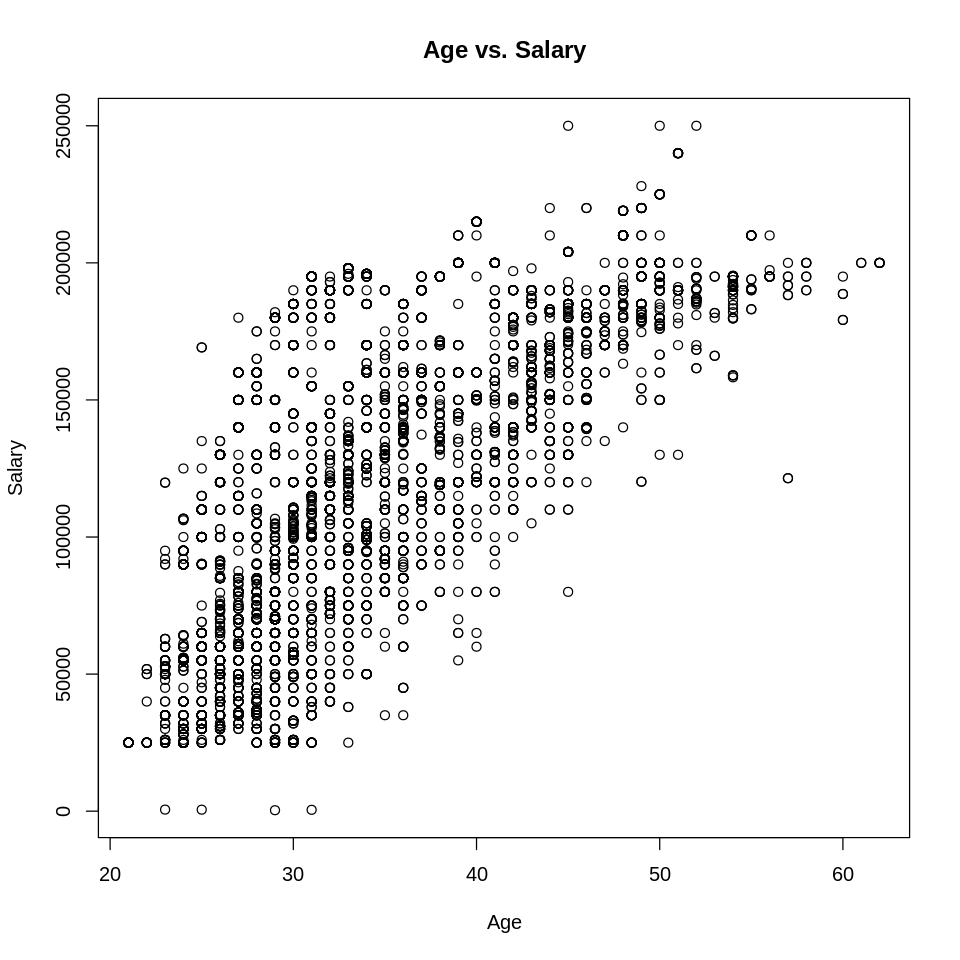

In [18]:
# optional to set plot dimansion
options(repr.plot.width = 8, repr.plot.height = 8)

# 2.1
plot(salary$Age, salary$Salary,
  xlab = "Age",
  ylab = "Salary",
  main = "Age vs. Salary")

<font color=red>Task 2.2</font> In a text cell, write your observations from the scatterplot from Task 2.1.

For example,
  * Is there a relationship between salary and age?
  * Is the relationship linear?
  * What is the approximate average salary of an individual who is in their mid 20's?
  * What is the approximate average salary of an individual who is in their mid 50's?
  * Which age has the highest variability in salary?

We could claim there is a approximate linear relationship or we could claim there appears to be a logorithmic relationship between `age` and `salary`. Older individuals tend to earn a higher salary, but the increases in salary diminish with increasing age. Individuals in their mid- 20s tend to earn around ~ \$60k per year. In contrast, individuals in their mid-50s tend to earn ~ \$175k per year. The highest variability in salaries is for individuals around 30 years old.

<br>

<br>

<br>

---

####<font color=red>Task 3</font> - Boxplots



<font color=red>Task 3.1</font> Plot a boxplot with `Salary` on the y-axis and `Gender` on the x-axis. Be sure to label you x-axis and y-axis accordingly using the `xlab` and `ylab` arguments in the `boxplot()` function.

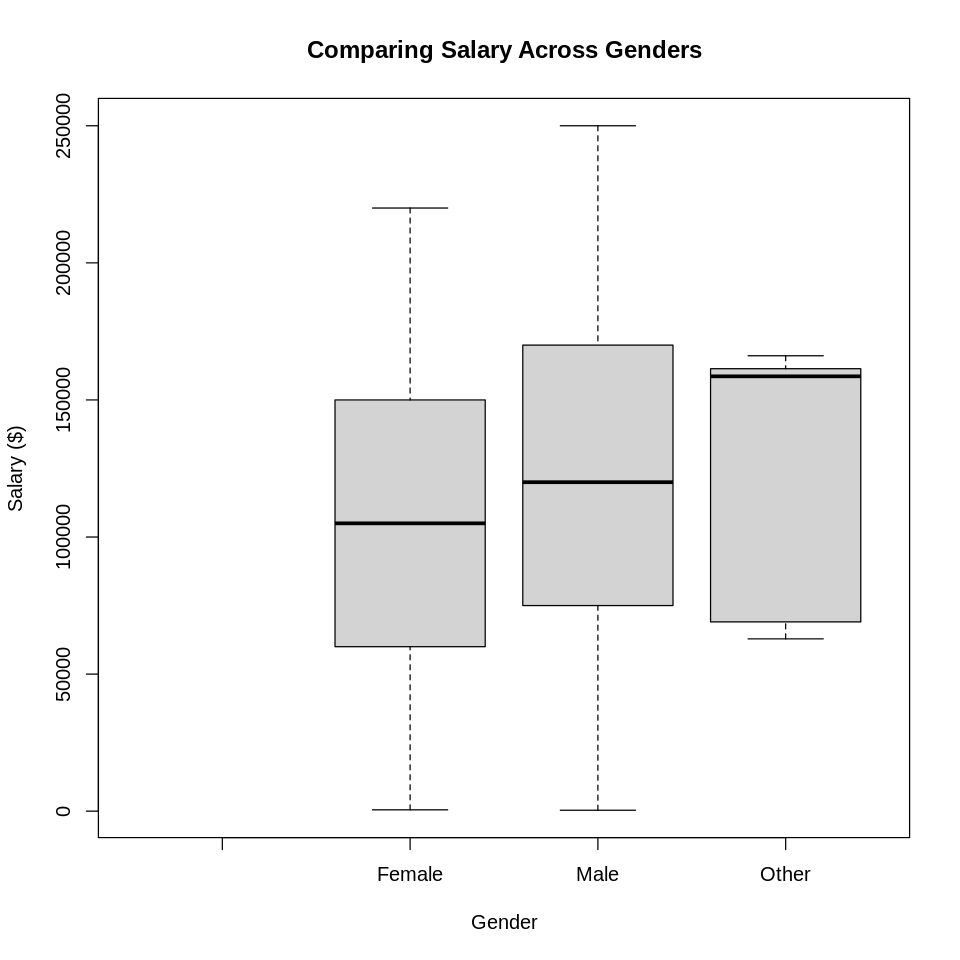

In [19]:
# optional
options(repr.plot.width = 8, repr.plot.height = 8)

# 3.1
boxplot(salary$Salary ~ salary$Gender,
        xlab = "Gender",
        ylab = "Salary ($)",
        main = "Comparing Salary Across Genders")

In [20]:
table(salary$Gender)


       Female   Male  Other 
     2   3014   3674     14 

<br>

<font color=red>Task 3.2</font> In a text cell, write your observations from the boxplot from Task 3.1. Include observations about the medians, quartiles, and variability for female and male individuals.

The median salary for Males is higher than the median salary for Females. The quartile for Other is higher than Male and Female.

<br>

<font color=red>Task 3.3</font> Plot a boxplot with `Salary` on the y-axis and `Education.Level` on the x-axis. Be sure to label your x-axis and y-axis accordingly using the `xlab` and `ylab` arguments in the `boxplot()` function.

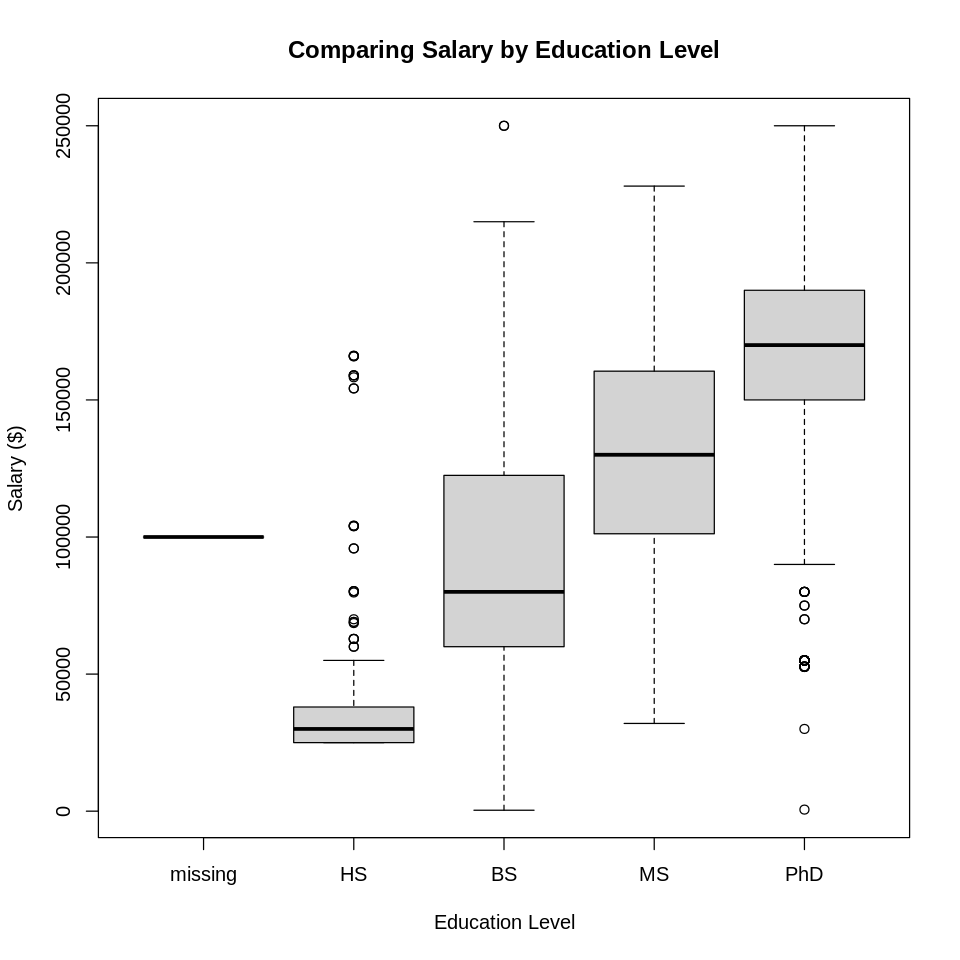

In [21]:
# optional
options(repr.plot.width = 8, repr.plot.height = 8)

# 3.3
boxplot(salary$Salary ~ salary$Education.Level,
        xlab = "Education Level",
        ylab = "Salary ($)",
        main = "Comparing Salary by Education Level")


In [23]:
table(salary$Education.Level)


missing      HS      BS      MS     PhD 
      3     448    3023    1861    1369 

<br>

<font color=red>Task 3.4</font> In a text cell, write your observations from the boxplot from Task 3.3. Include observations about the medians, quartiles, variability, and outliers.

People with a PhD have less variablility in salary in comparison to people who have earned a MS, BS, and HS. There are more outliers in those hwo have obtained a HS diploma in comparison to all other education levels.

<br>

<br>

<br>

---

####<font color=red>Task 4</font> - Heatmaps



<font color=red>Task 4.1</font> Create a heatmap from a frequency table with `Job.Title` and `Education.Level` as the variables.

You can use the following code to adjust the width and height of the plot:
`options(repr.plot.width=15, repr.plot.height=35)`


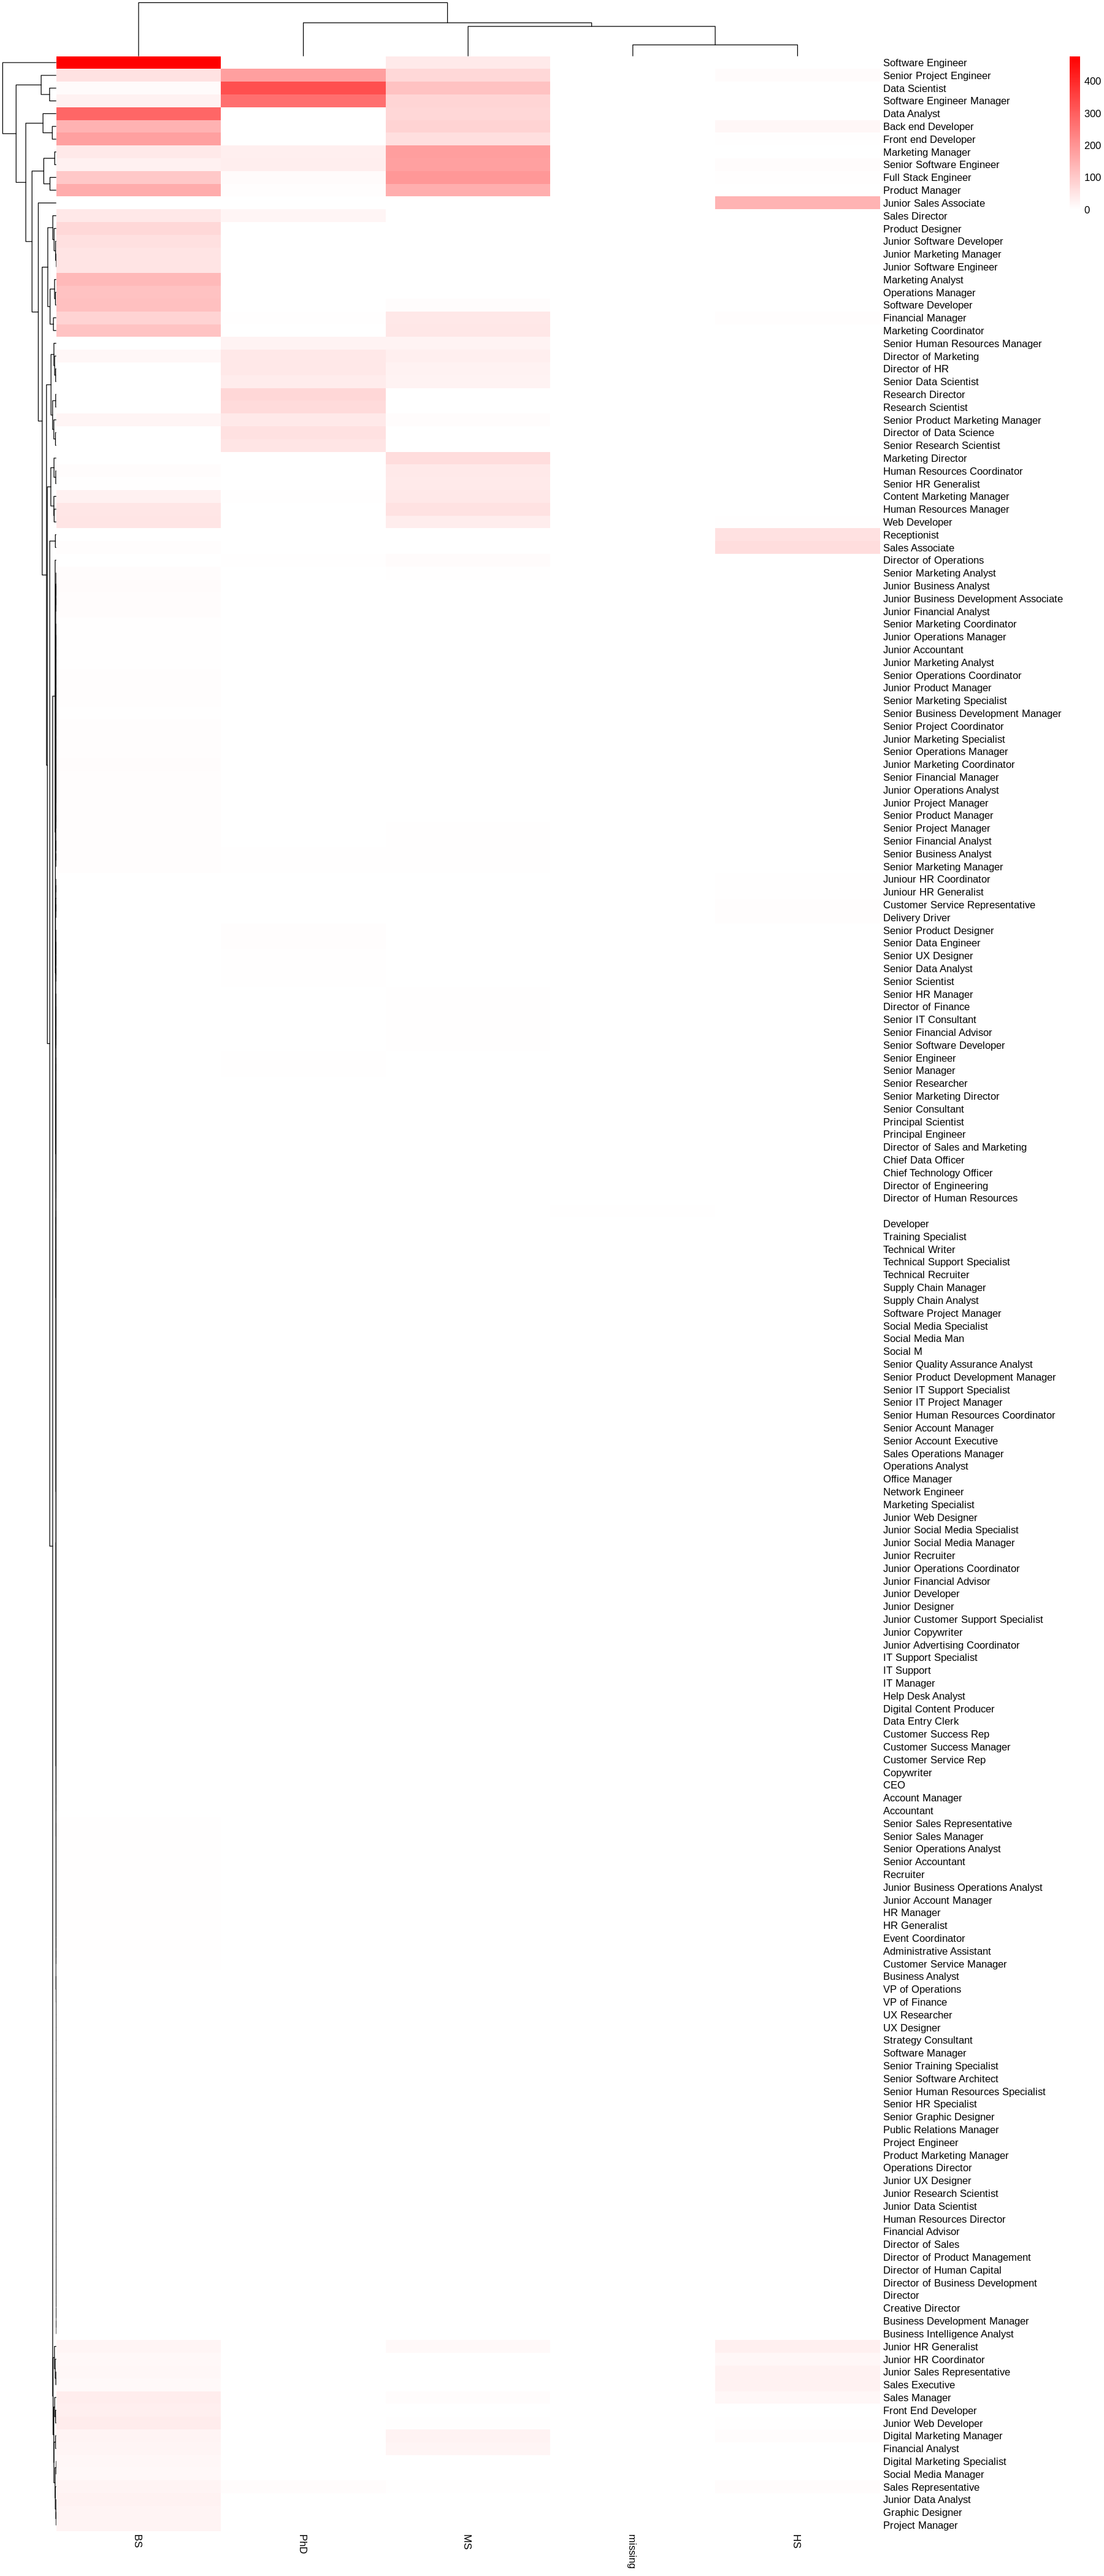

In [28]:
options(repr.plot.width= 15, repr.plot.height= 35)

# create the frequency table
table_data <- table(salary$Job.Title, salary$Education.Level)

# generat heatmap using pheatmap
pheatmap(table_data,
         col = colorRampPalette(c("white", "red"))(256)) #specifies color range for heatmap

<br>

<font color=red>Task 4.2</font> Write your observations in a text cell.

* In this dataset, what are the most common jobs amongst individuals with HS degrees? BS degrees? MS degrees? PhD degrees?
* Is there anything else you observe from the heatmap?

High school ghraduate tend to be sales associates. Mnay individuals with bachelor's degrees tend to be software engineers. The jobs of individuals with master's degrees vary between engineering and markteing. Individuals with PhD tend ot be data scientists or managers.

<br>

<font color=red>Task 4.3</font> Run the following script, which creates a new data frame called `salary_common`. This new data frame only includes the common job titles.

```
job_table     <- table(salary$Job.Title)
salary_common <- salary[salary$Job.Title %in% (names(job_table)[job_table > 100]),]
```

* Replot your heatmap using the data frame `salary_common`

In [29]:
job_table     <- table(salary$Job.Title)
salary_common <- salary[salary$Job.Title %in% (names(job_table)[job_table > 100]),]

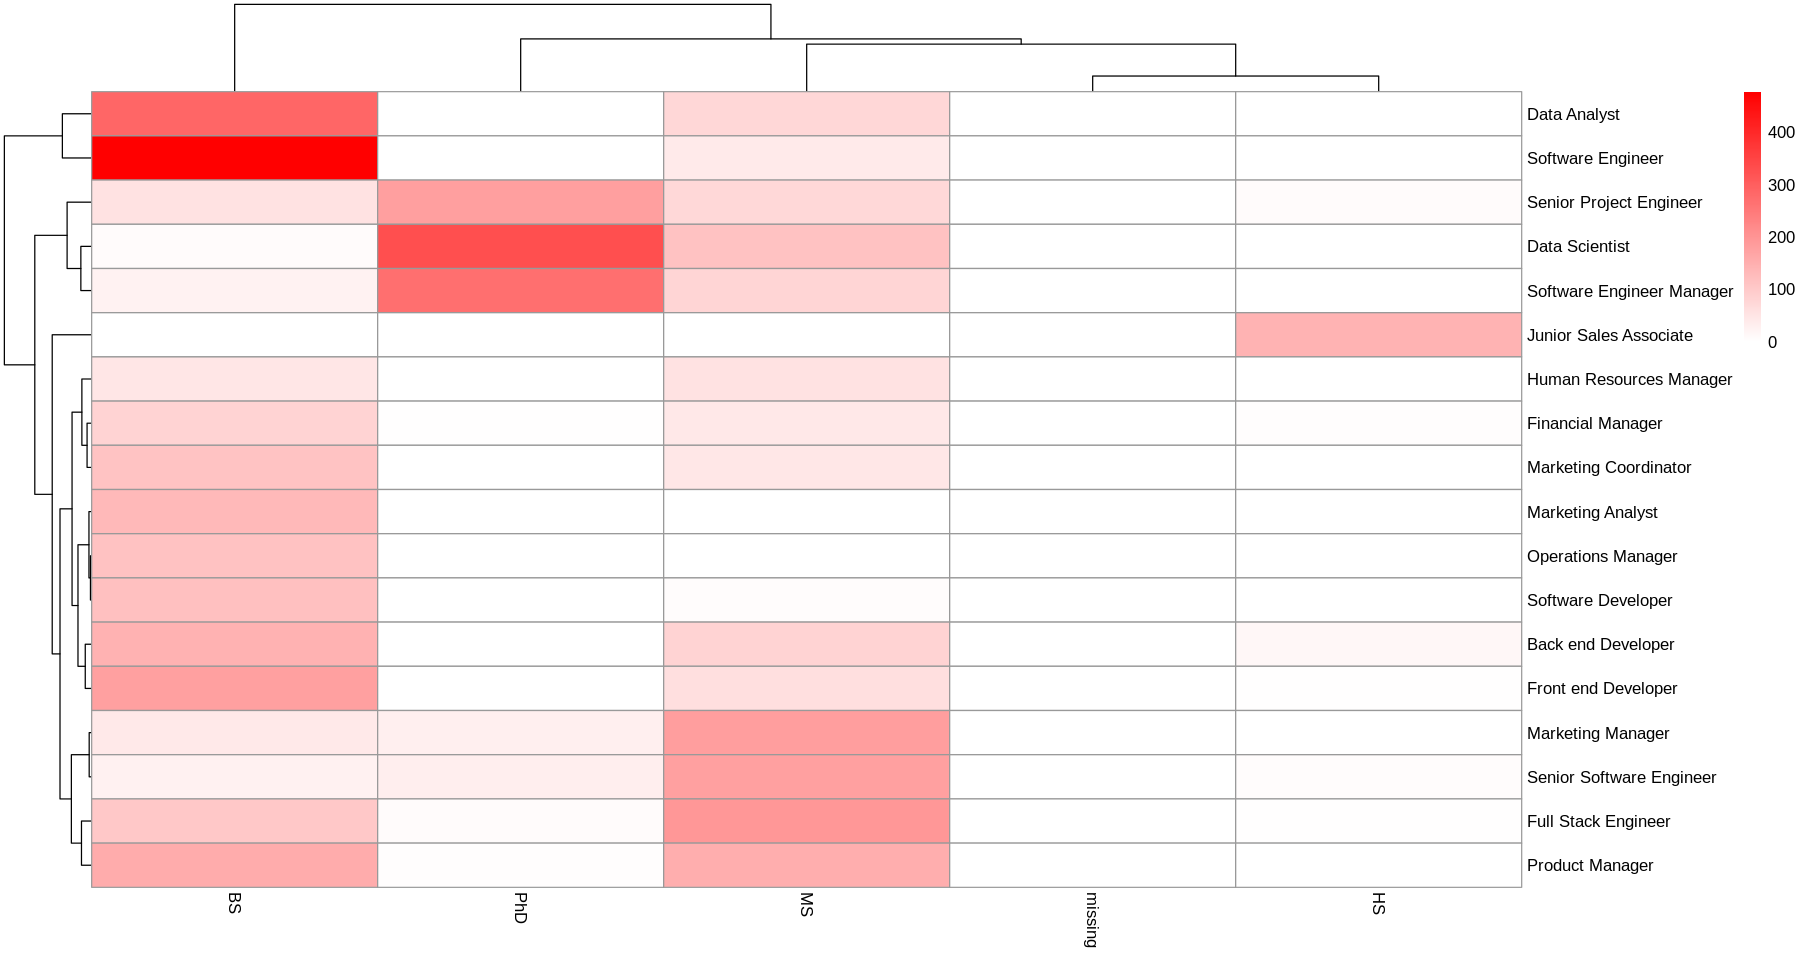

In [30]:
options(repr.plot.width= 15, repr.plot.height= 8)

# create the frequency table
table_data <- table(salary_common$Job.Title, salary_common$Education.Level)

# generat heatmap using pheatmap
pheatmap(table_data,
         col = colorRampPalette(c("white", "red"))(256)) #specifies color range for heatmap

<br>

<br>